# GLIPH-like Multi-family Enrichment and Combined Graph Clustering (TRB)

This notebook implements a GLIPH-style workflow on TRB clonotypes with expanded token families and a combined graph stage:

1. Load `gliph_trb.tsv.gz` from the local benchmark cache.
2. Collapse each study to a unique list of `(v_gene, junction_aa)` clonotypes before token counting.
3. Build five token families per clonotype:
   - **v+3-mer**
   - **v+pos+3-mer**
   - **ungapped 4-mer**
   - **gapped 4-mer**
   - **gapped 5-mer**
4. For each study and family, run Fisher enrichment against a **V-only matched** real TRB control sample of size `1,000,000`.
5. Plot separate volcano plots for each family/study pair with the enrichment cutoff `FDR < 0.05` and `odds > 1.0`.
6. Combine all enriched tokens into one bipartite k-mer/clonotype graph per study.
7. Project that graph to clonotype and k-mer graphs, then evaluate component/community concordance against `stimulus` and `gliph_cluster_id`.

The implementation intentionally reuses `mir/**` components for token extraction, control normalization, and Fisher-based enrichment.

In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from itertools import combinations
from pathlib import Path
import re

import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from mir.biomarkers.gliph import (
    GliphTokenArtifacts,
    deduplicate_clonotype_rows,
    extract_g4mer_artifacts,
    extract_g5mer_artifacts,
    extract_u4mer_artifacts,
    extract_v3mer_artifacts,
    extract_vpos3mer_artifacts,
    normalize_control_v,
 )
from mir.biomarkers.kmer_stats import compare_kmer_counts
from mir.common.control import ControlManager
from mir.utils.notebook_assets import ensure_airr_benchmark, find_repo_root


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
# --- Reproducibility & paths ---
import sys
repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
print('repo_root:', repo_root)

REPO_GLPH_PATH = repo_root / 'airr_benchmark' / 'gliph' / 'gliph_trb.tsv.gz'
NOTEBOOK_GLPH_PATH = repo_root / 'notebooks' / 'assets' / 'large' / 'airr_benchmark' / 'gliph' / 'gliph_trb.tsv.gz'
HF_PATTERN = ['gliph/gliph_trb.tsv.gz']
FORCE_HF_REFRESH = False
CONTROL_LABELS = {'control', 'healthy_control', 'healthy', 'naive', 'unstimulated'}

# --- Analysis parameters ---
CONTROL_SAMPLE = 1_000_000
TOKEN_THREADS = 4
COUNT_MODE = 'clonotype'
KMER_PSEUDOCOUNT = 1
SIG_FDR = 0.05
SIG_ODDS = 1.0
TOP_LABELS = 10
MIN_CLUSTER_SIZE = 3
MIN_TOKEN_CLONOTYPES = 2
MAX_GRAPH_NODES = 450
CLONE_EDGE_MIN_WEIGHT = 0.35
SEED = 42

FAMILIES = ['v3', 'vpos3', 'u4', 'g4', 'g5']
FAMILY_LABELS = {
    'v3': 'V+3-mer',
    'vpos3': 'V+pos+3-mer',
    'u4': 'Ungapped 4-mer',
    'g4': 'Gapped 4-mer',
    'g5': 'Gapped 5-mer',
}
FAMILY_COLORS = {
    'v3': '#e76f51',
    'vpos3': '#f4a261',
    'u4': '#2a9d8f',
    'g4': '#457b9d',
    'g5': '#6d597a',
}
STIMULUS_PALETTE = {
    'MegaIL2': '#d62828',
    'CMV': '#003049',
    'EBV': '#6a994e',
    'YellowFever': '#ffb703',
    'influenza': '#8ecae6',
}
CLUSTER_METHODS = ['components', 'leiden']
STUDY_KEYWORDS = {
    'Glanville2017': 'glanville',
    'Huang2020': 'huang',
}

AA_RE = re.compile(r'^[ACDEFGHIKLMNPQRSTVWY]+$')


repo_root: /Users/mikesh/vcs/mirpy


In [3]:
def _pick_col(df: pd.DataFrame, candidates: list[str], required: bool = True) -> str | None:
    existing = {c.lower(): c for c in df.columns}
    for c in candidates:
        got = existing.get(c.lower())
        if got is not None:
            return got
    if required:
        raise KeyError(f'Missing required column. Tried: {candidates}. Available: {list(df.columns)}')
    return None


def _resolve_gliph_path(force_hf_refresh: bool = FORCE_HF_REFRESH) -> Path:
    if REPO_GLPH_PATH.exists() and not force_hf_refresh:
        return REPO_GLPH_PATH
    if NOTEBOOK_GLPH_PATH.exists() and not force_hf_refresh:
        return NOTEBOOK_GLPH_PATH
    ds_root = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=HF_PATTERN)
    path = ds_root / 'gliph' / 'gliph_trb.tsv.gz'
    if not path.exists():
        raise FileNotFoundError(f'Could not find gliph_trb.tsv.gz at {path}')
    return path


def _normalize_df(raw: pd.DataFrame) -> pd.DataFrame:
    c_seq = _pick_col(raw, ['junction_aa', 'cdr3aa', 'cdr3'])
    c_v = _pick_col(raw, ['v_gene', 'v', 'v.segm'])
    c_j = _pick_col(raw, ['j_gene', 'j', 'j.segm'], required=False)
    c_dc = _pick_col(raw, ['duplicate_count', 'count', 'read.count'], required=False)
    c_study = _pick_col(raw, ['reference_id', 'study_id', 'study'])
    c_donor = _pick_col(raw, ['donor_id', 'donor', 'subject_id'], required=False)
    c_stim = _pick_col(raw, ['stimulus', 'status', 'condition'])
    c_ep = _pick_col(raw, ['epitope', 'antigen.epitope'], required=False)
    c_gliph = _pick_col(raw, ['gliph_cluster_id', 'cluster_id'], required=False)

    out = pd.DataFrame({
        'junction_aa': raw[c_seq].astype(str).str.strip(),
        'v_gene': raw[c_v].astype(str).str.strip(),
        'j_gene': raw[c_j].astype(str).str.strip() if c_j else '',
        'duplicate_count': pd.to_numeric(raw[c_dc], errors='coerce').fillna(1).astype(int) if c_dc else 1,
        'reference_id': raw[c_study].astype(str).str.strip(),
        'donor_id': raw[c_donor].astype(str).str.strip() if c_donor else 'unknown',
        'stimulus': raw[c_stim].astype(str).str.strip(),
        'epitope': raw[c_ep].astype(str).str.strip() if c_ep else '',
        'gliph_cluster_id': raw[c_gliph].astype(str).str.strip() if c_gliph else '',
    })
    out = out[out['junction_aa'].str.len() >= 5].copy()
    out = out[out['junction_aa'].str.match(AA_RE)].copy()
    out['v_base'] = out['v_gene'].str.split('*').str[0]
    out['is_control'] = out['stimulus'].str.lower().isin(CONTROL_LABELS)
    out = out.reset_index(drop=True)
    out['row_id'] = out.index.astype(str)
    return out


def _deduplicate_gliph_df(df_in: pd.DataFrame) -> pd.DataFrame:
    dedup = deduplicate_clonotype_rows(
        df_in,
        subset=('reference_id', 'junction_aa', 'v_gene'),
    )
    dedup['v_base'] = dedup['v_gene'].astype(str).str.split('*').str[0]
    dedup['is_control'] = dedup['stimulus'].astype(str).str.lower().isin(CONTROL_LABELS)
    return dedup


def _duplicate_summary(df_raw: pd.DataFrame, df_unique: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for study, sdf in df_raw.groupby('reference_id', sort=True):
        unique_sdf = df_unique[df_unique['reference_id'] == study]
        rows.append({
            'reference_id': study,
            'raw_rows': len(sdf),
            'unique_v_junction_clonotypes': len(unique_sdf),
            'removed_duplicates': len(sdf) - len(unique_sdf),
            'with_gliph_cluster_id': int((unique_sdf['gliph_cluster_id'].fillna('').astype(str).str.strip() != '').sum()),
            'with_epitope': int((unique_sdf['epitope'].fillna('').astype(str).str.strip() != '').sum()),
        })
    return pd.DataFrame(rows).sort_values('reference_id').reset_index(drop=True)


In [4]:
gliph_path = _resolve_gliph_path()
raw_df = pd.read_csv(gliph_path, sep='\t', compression='infer')
df_raw = _normalize_df(raw_df)
df = _deduplicate_gliph_df(df_raw)
duplicate_summary = _duplicate_summary(df_raw, df)

print(f'Loaded {len(raw_df):,} raw rows from {gliph_path}')
print(f'Using {len(df):,} unique clonotypes for token counting and clustering')
print('Columns in raw GLIPH table:', ', '.join(raw_df.columns))
display(duplicate_summary)
display(df.head(3))

Loaded 17,936 raw rows from /Users/mikesh/vcs/mirpy/airr_benchmark/gliph/gliph_trb.tsv.gz
Using 13,862 unique clonotypes for token counting and clustering
Columns in raw GLIPH table: junction_aa, v_gene, j_gene, donor_id, duplicate_count, locus, reference_id, stimulus, epitope, gliph_cluster_id


,reference_id,raw_rows,unique_v_junction_clonotypes,removed_duplicates,with_gliph_cluster_id,with_epitope
0,Glanville2017,7433,3928,3505,1287,0
1,Huang2020,10501,9934,567,4493,0


,reference_id,junction_aa,v_gene,j_gene,duplicate_count,donor_id,stimulus,epitope,gliph_cluster_id,v_base,is_control,row_id
0,Glanville2017,CASSPNGIMNTEAFF,TRBV7-6,TRBJ1-1,50835,09/0018,MegaIL2,None,C3282,TRBV7-6,False,0
1,Glanville2017,CASTQSGGTNEKLFF,TRBV28,TRBJ1-4,110298,09/0018,MegaIL2,None,C3374,TRBV28,False,1
2,Glanville2017,CASSAWDRGRFTEAFF,TRBV25-1,TRBJ1-1,91536,09/0018,MegaIL2,None,C626,TRBV25-1,False,2


In [5]:
# Load the real human TRB control repertoire from mir's built-in control cache.
ctrl_manager = ControlManager()
print('Loading real human TRB control (downloads on first run)...')
ctrl_raw = ctrl_manager.ensure_and_load_control_df('real', 'human', 'TRB')
print(f'Full control: {len(ctrl_raw):,} rows   columns: {list(ctrl_raw.columns[:5])}')

ctrl_all = pd.DataFrame({
    'junction_aa': ctrl_raw['junction_aa'].astype(str).str.strip(),
    'v_gene': ctrl_raw['v_gene'].astype(str).str.strip(),
    'j_gene': ctrl_raw['j_gene'].astype(str).str.strip(),
    'duplicate_count': pd.to_numeric(ctrl_raw.get('duplicate_count', 1), errors='coerce').fillna(1).astype(int),
    'stimulus': 'control',
    'reference_id': 'control',
    'epitope': '',
    'gliph_cluster_id': '',
})
ctrl_all = ctrl_all[
    ctrl_all['junction_aa'].str.match(AA_RE)
    & (ctrl_all['junction_aa'].str.len() >= 5)
].copy()

ctrl_by_study: dict[str, pd.DataFrame] = {}
for study, sdf in df.groupby('reference_id', sort=True):
    print(f'\nNormalising control V usage to {study} ({len(sdf):,} unique V+junction clonotypes)...')
    ctrl_norm = normalize_control_v(sdf, ctrl_all, n=CONTROL_SAMPLE, seed=SEED)
    ctrl_by_study[str(study)] = ctrl_norm
    print(f'  -> {len(ctrl_norm):,} control clonotypes (duplicate_count=1, V-matched)')

display(ctrl_by_study[next(iter(ctrl_by_study))].head(3))

Loading real human TRB control (downloads on first run)...
Full control: 28,257,621 rows   columns: ['duplicate_count', 'junction', 'junction_aa', 'v_gene', 'j_gene']

Normalising control V usage to Glanville2017 (3,928 unique V+junction clonotypes)...
  -> 1,000,000 control clonotypes (duplicate_count=1, V-matched)

Normalising control V usage to Huang2020 (9,934 unique V+junction clonotypes)...
  -> 1,000,000 control clonotypes (duplicate_count=1, V-matched)


,junction_aa,v_gene,j_gene,duplicate_count,stimulus,reference_id,epitope,gliph_cluster_id,row_id
0,CASSEDKNIQYF,TRBV10-1*01,TRBJ2-4*01,1,control,control,,,ctrl_0
1,CASSESTVGFGETQYF,TRBV10-1*01,TRBJ2-5*01,1,control,control,,,ctrl_1
2,CASSVSGTYNEQFF,TRBV10-1*01,TRBJ2-1*01,1,control,control,,,ctrl_2


## Tokenization and Fisher Enrichment

Each token family is tested separately with Fisher exact tests.

- Sample clonotypes are deduplicated first to unique `(reference_id, v_gene, junction_aa)` rows.
- Controls are resampled to match **V usage only**.
- The enrichment cutoff for downstream graph construction is `FDR < 0.05`, `odds > 1.0`, and at least `2` supporting clonotypes.

In [6]:
FAMILY_EXTRACTORS = {
    'v3': extract_v3mer_artifacts,
    'vpos3': extract_vpos3mer_artifacts,
    'u4': extract_u4mer_artifacts,
    'g4': extract_g4mer_artifacts,
    'g5': extract_g5mer_artifacts,
}


def _extract_family_artifacts(clonotype_df: pd.DataFrame, family: str) -> GliphTokenArtifacts:
    return FAMILY_EXTRACTORS[family](
        clonotype_df,
        threads=TOKEN_THREADS,
        count_mode=COUNT_MODE,
        unique_clonotypes=False,
    )


def _run_enrichment(
    sample_art: GliphTokenArtifacts,
    ctrl_art: GliphTokenArtifacts,
 ) -> pd.DataFrame:
    return compare_kmer_counts(
        sample_art.counts,
        ctrl_art.counts,
        test='fisher',
        p_adj_method='fdr_bh',
        pseudocount=KMER_PSEUDOCOUNT,
    )


def _significant_tokens(comp: pd.DataFrame, sample_art: GliphTokenArtifacts) -> tuple[pd.DataFrame, pd.Series]:
    support = pd.Series(sample_art.clonotype_counts, name='sample_clonotypes')
    comp = comp.join(support, how='left').fillna({'sample_clonotypes': 0})
    comp['sample_clonotypes'] = comp['sample_clonotypes'].astype(int)
    sig_mask = (
        (comp['p_val_adj'] < SIG_FDR)
        & (comp['odds_ratio'] > SIG_ODDS)
        & (comp['sample_clonotypes'] >= MIN_TOKEN_CLONOTYPES)
    )
    return comp, sig_mask


def _family_from_token(token: str) -> str:
    return token.split('::', 1)[0]


def _token_display_name(token: str) -> str:
    parts = token.split('::')
    family = parts[0]
    if family == 'v3':
        return f"{parts[1]}:{parts[2]}"
    if family == 'vpos3':
        return f"{parts[1]}@{parts[2]}:{parts[3]}"
    return parts[1]


In [7]:
# study_results[family][study] contains:
#   'study_art'       : GliphTokenArtifacts for sample
#   'ctrl_art'        : GliphTokenArtifacts for VJ-normalised control
#   'comparison'      : enrichment DataFrame from compare_kmer_counts
#   'sig_mask'        : significant token mask after support filtering
#   'enriched_tokens' : selected tokens for graphing/clustering
study_results: dict[str, dict] = {fam: {} for fam in FAMILIES}
enrichment_overview_rows: list[dict[str, object]] = []

for study, sdf in df.groupby('reference_id', sort=True):
    study = str(study)
    ctrl_df = ctrl_by_study[study]
    print(f'\n=== {study} ===')

    for family in FAMILIES:
        print(f'  Tokenising {FAMILY_LABELS[family]} with {TOKEN_THREADS} threads...')
        sample_art = _extract_family_artifacts(sdf, family)
        ctrl_art = _extract_family_artifacts(ctrl_df, family)
        comp = _run_enrichment(sample_art, ctrl_art)
        comp, sig_mask = _significant_tokens(comp, sample_art)
        enriched_tokens = set(comp.index[sig_mask])

        study_results[family][study] = {
            'study_art': sample_art,
            'ctrl_art': ctrl_art,
            'comparison': comp,
            'sig_mask': sig_mask,
            'enriched_tokens': enriched_tokens,
            'study_df': sdf,
        }
        enrichment_overview_rows.append({
            'reference_id': study,
            'family': family,
            'token_family': FAMILY_LABELS[family],
            'n_tokens_total': len(comp),
            'n_tokens_sig': int(sig_mask.sum()),
            'median_sample_clonotypes': float(comp['sample_clonotypes'].median()),
        })
        print(f'    -> {int(sig_mask.sum())} enriched tokens ({len(comp)} total)')

enrichment_overview = pd.DataFrame(enrichment_overview_rows).sort_values(
    ['reference_id', 'family']
).reset_index(drop=True)
display(enrichment_overview)



=== Glanville2017 ===
  Tokenising V+3-mer with 4 threads...
    -> 442 enriched tokens (214308 total)
  Tokenising V+pos+3-mer with 4 threads...
    -> 206 enriched tokens (865660 total)
  Tokenising Ungapped 4-mer with 4 threads...
    -> 20 enriched tokens (108985 total)
  Tokenising Gapped 4-mer with 4 threads...
    -> 109 enriched tokens (30895 total)
  Tokenising Gapped 5-mer with 4 threads...
    -> 74 enriched tokens (538440 total)

=== Huang2020 ===
  Tokenising V+3-mer with 4 threads...
    -> 962 enriched tokens (220095 total)
  Tokenising V+pos+3-mer with 4 threads...
    -> 470 enriched tokens (854924 total)
  Tokenising Ungapped 4-mer with 4 threads...
    -> 544 enriched tokens (109068 total)
  Tokenising Gapped 4-mer with 4 threads...
    -> 1608 enriched tokens (30983 total)
  Tokenising Gapped 5-mer with 4 threads...
    -> 2163 enriched tokens (539636 total)


,reference_id,family,token_family,n_tokens_total,n_tokens_sig,median_sample_clonotypes
0,Glanville2017,g4,Gapped 4-mer,30895,109,1.0
1,Glanville2017,g5,Gapped 5-mer,538440,74,0.0
2,Glanville2017,u4,Ungapped 4-mer,108985,20,0.0
3,Glanville2017,v3,V+3-mer,214308,442,0.0
4,Glanville2017,vpos3,V+pos+3-mer,865660,206,0.0
5,Huang2020,g4,Gapped 4-mer,30983,1608,2.0
6,Huang2020,g5,Gapped 5-mer,539636,2163,0.0
7,Huang2020,u4,Ungapped 4-mer,109068,544,0.0
8,Huang2020,v3,V+3-mer,220095,962,0.0
9,Huang2020,vpos3,V+pos+3-mer,854924,470,0.0


## Separate Volcano Plots by Family and Study

Each panel shows one family/study Fisher comparison. Tokens passing `FDR < 0.05`, `odds > 1.0`, and `sample_clonotypes >= 2` are highlighted in red.

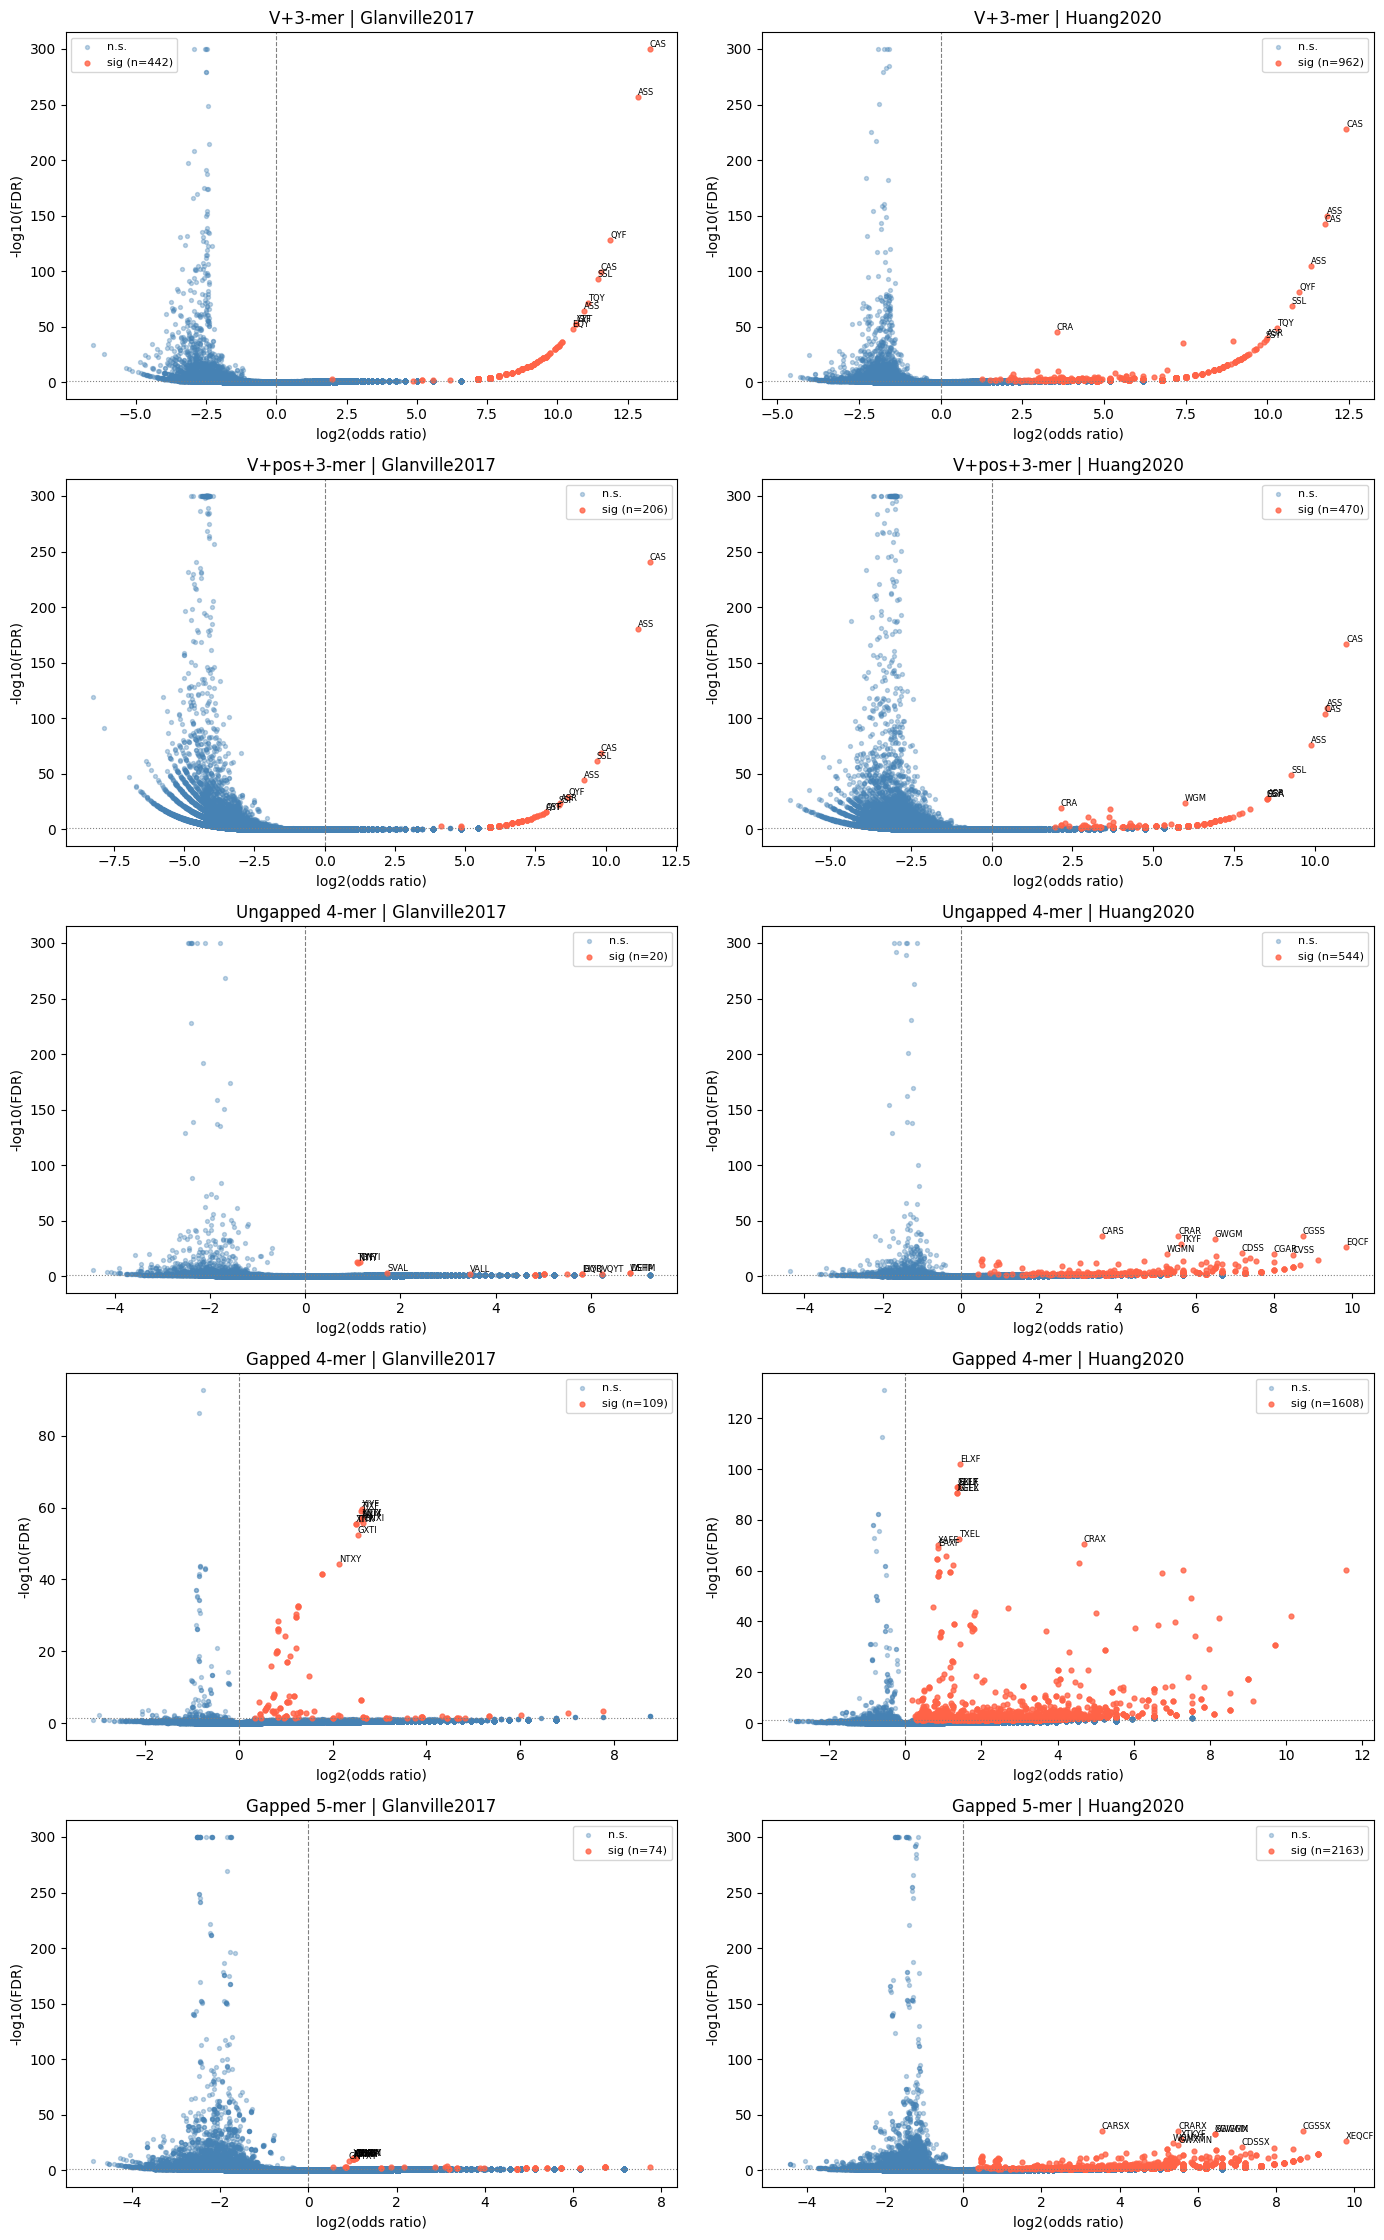

In [8]:
studies = sorted(next(iter(study_results.values())).keys())
n_studies = len(studies)

fig, axes = plt.subplots(
    nrows=len(FAMILIES),
    ncols=n_studies,
    figsize=(7 * n_studies, 4.5 * len(FAMILIES)),
    squeeze=False,
)

for row_i, family in enumerate(FAMILIES):
    for col_i, study in enumerate(studies):
        ax = axes[row_i, col_i]
        comp = study_results[family][study]['comparison'].copy()
        sig = study_results[family][study]['sig_mask']
        comp['log2or'] = np.log2(comp['odds_ratio'].clip(lower=1e-6))
        comp['neglog10p'] = -np.log10(comp['p_val_adj'].clip(lower=1e-300))

        ax.scatter(
            comp.loc[~sig, 'log2or'],
            comp.loc[~sig, 'neglog10p'],
            s=8, alpha=0.35, color='steelblue', label='n.s.'
        )
        ax.scatter(
            comp.loc[sig, 'log2or'],
            comp.loc[sig, 'neglog10p'],
            s=12, alpha=0.8, color='tomato', label=f'sig (n={int(sig.sum())})'
        )

        top = comp[sig].nlargest(TOP_LABELS, 'neglog10p')
        for _, row in top.iterrows():
            token_label = row.name.split('::', 3)[-1] if '::' in row.name else row.name
            ax.annotate(token_label, xy=(row['log2or'], row['neglog10p']), fontsize=6, ha='left', va='bottom')

        ax.axvline(np.log2(SIG_ODDS), color='grey', linestyle='--', linewidth=0.8)
        ax.axhline(-np.log10(SIG_FDR), color='grey', linestyle=':', linewidth=0.8)
        ax.set_xlabel('log2(odds ratio)')
        ax.set_ylabel('-log10(FDR)')
        ax.set_title(f'{FAMILY_LABELS[family]} | {study}')
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Combined Enriched-token Graphs

For each study, all enriched k-mers from all five families are merged into one combined graph.

- Bipartite graph: k-mer nodes are colored by token family, clonotypes are grey.
- Clonotype projection: clonotypes are connected if they share at least one enriched k-mer.
- K-mer projection: k-mers are connected if at least one clonotype contains both.

In [14]:
def _build_combined_token_maps(study_payloads: dict[str, dict[str, object]]) -> tuple[dict[str, set[str]], dict[str, set[str]], dict[str, str]]:
    token_to_clones: dict[str, set[str]] = defaultdict(set)
    clone_to_tokens: dict[str, set[str]] = defaultdict(set)
    token_family: dict[str, str] = {}
    for family, payload in study_payloads.items():
        sample_art: GliphTokenArtifacts = payload['study_art']
        for token in payload['enriched_tokens']:
            clone_ids = set(sample_art.token_to_clone.get(token, set()))
            if not clone_ids:
                continue
            token_to_clones[token].update(clone_ids)
            token_family[token] = family
            for clone_id in clone_ids:
                clone_to_tokens[clone_id].add(token)
    return dict(token_to_clones), dict(clone_to_tokens), token_family


def _stimulus_color_map(values: pd.Series) -> dict[str, str]:
    unique_values = [v for v in sorted(values.fillna('').astype(str).str.strip().unique()) if v]
    fallback = ['#bc6c25', '#219ebc', '#b5179e', '#588157', '#ff7f11', '#4d908e']
    colors = {}
    for idx, value in enumerate(unique_values):
        colors[value] = STIMULUS_PALETTE.get(value, fallback[idx % len(fallback)])
    return colors


def _build_bipartite_graph(
    study_df: pd.DataFrame,
    token_to_clones: dict[str, set[str]],
    token_family: dict[str, str],
) -> ig.Graph:
    token_nodes = sorted(token_to_clones)
    clone_nodes = sorted({clone_id for clone_ids in token_to_clones.values() for clone_id in clone_ids})
    all_nodes = token_nodes + clone_nodes
    node_idx = {name: i for i, name in enumerate(all_nodes)}
    graph = ig.Graph(n=len(all_nodes), directed=False)
    graph.vs['name'] = all_nodes
    graph.vs['kind'] = ['token'] * len(token_nodes) + ['clone'] * len(clone_nodes)

    edges = []
    for token, clone_ids in token_to_clones.items():
        for clone_id in sorted(clone_ids):
            edges.append((node_idx[token], node_idx[clone_id]))
    if edges:
        graph.add_edges(edges)

    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    graph.vs['color'] = [
        FAMILY_COLORS.get(token_family.get(v['name'], ''), '#999999') if v['kind'] == 'token' else '#9e9e9e'
        for v in graph.vs
    ]
    graph.vs['size'] = [
        5.0 + 1.4 * np.log2(len(token_to_clones.get(v['name'], set())) + 1.0) if v['kind'] == 'token'
        else 2.0 + 2.2 * np.log2(dup_map.get(v['name'], 1.0) + 1.0)
        for v in graph.vs
    ]
    return graph


def _project_clone_graph(
    study_df: pd.DataFrame,
    clone_to_tokens: dict[str, set[str]],
) -> ig.Graph:
    clone_nodes = sorted(clone_to_tokens)
    graph = ig.Graph(n=len(clone_nodes), directed=False)
    graph.vs['name'] = clone_nodes
    clone_idx = {clone_id: i for i, clone_id in enumerate(clone_nodes)}
    edge_weights: dict[tuple[int, int], int] = defaultdict(int)
    token_to_clones: dict[str, list[str]] = defaultdict(list)
    for clone_id, tokens in clone_to_tokens.items():
        for token in tokens:
            token_to_clones[token].append(clone_id)
    for clone_ids in token_to_clones.values():
        if len(clone_ids) < 2:
            continue
        for left, right in combinations(sorted(clone_ids), 2):
            edge = tuple(sorted((clone_idx[left], clone_idx[right])))
            edge_weights[edge] += 1
    if edge_weights:
        graph.add_edges(list(edge_weights.keys()))
        graph.es['weight'] = [float(weight) for weight in edge_weights.values()]

    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    stimulus_map = study_df.set_index('row_id')['stimulus'].astype(str).to_dict()
    stim_colors = _stimulus_color_map(study_df['stimulus'])
    graph.vs['color'] = [stim_colors.get(stimulus_map.get(name, ''), '#bdbdbd') for name in graph.vs['name']]
    graph.vs['size'] = [2.0 + 2.2 * np.log2(dup_map.get(name, 1.0) + 1.0) for name in graph.vs['name']]
    return graph


def _build_weighted_clone_graph(
    study_df: pd.DataFrame,
    token_to_clones: dict[str, set[str]],
    min_weight: float = CLONE_EDGE_MIN_WEIGHT,
) -> ig.Graph:
    clone_nodes = sorted({clone_id for clone_ids in token_to_clones.values() for clone_id in clone_ids})
    graph = ig.Graph(n=len(clone_nodes), directed=False)
    graph.vs['name'] = clone_nodes
    clone_idx = {clone_id: i for i, clone_id in enumerate(clone_nodes)}
    edge_weights: dict[tuple[int, int], float] = defaultdict(float)
    for clone_ids in token_to_clones.values():
        ordered = sorted(clone_ids)
        degree = len(ordered)
        if degree < 2:
            continue
        contribution = 1.0 / max(1.0, float(degree - 1))
        for left, right in combinations(ordered, 2):
            edge = tuple(sorted((clone_idx[left], clone_idx[right])))
            edge_weights[edge] += contribution
    keep_edges = [(edge, weight) for edge, weight in edge_weights.items() if weight >= min_weight]
    if keep_edges:
        graph.add_edges([edge for edge, _ in keep_edges])
        graph.es['weight'] = [float(weight) for _, weight in keep_edges]

    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    stimulus_map = study_df.set_index('row_id')['stimulus'].astype(str).to_dict()
    stim_colors = _stimulus_color_map(study_df['stimulus'])
    graph.vs['color'] = [stim_colors.get(stimulus_map.get(name, ''), '#bdbdbd') for name in graph.vs['name']]
    graph.vs['size'] = [2.0 + 2.2 * np.log2(dup_map.get(name, 1.0) + 1.0) for name in graph.vs['name']]
    return graph


def _project_kmer_graph(
    study_df: pd.DataFrame,
    token_to_clones: dict[str, set[str]],
    token_family: dict[str, str],
) -> ig.Graph:
    token_nodes = sorted(token_to_clones)
    graph = ig.Graph(n=len(token_nodes), directed=False)
    graph.vs['name'] = token_nodes
    token_idx = {token: i for i, token in enumerate(token_nodes)}
    edge_weights: dict[tuple[int, int], int] = defaultdict(int)
    clone_to_tokens: dict[str, list[str]] = defaultdict(list)
    for token, clone_ids in token_to_clones.items():
        for clone_id in clone_ids:
            clone_to_tokens[clone_id].append(token)
    for tokens in clone_to_tokens.values():
        if len(tokens) < 2:
            continue
        for left, right in combinations(sorted(tokens), 2):
            edge = tuple(sorted((token_idx[left], token_idx[right])))
            edge_weights[edge] += 1
    if edge_weights:
        graph.add_edges(list(edge_weights.keys()))
        graph.es['weight'] = [float(weight) for weight in edge_weights.values()]

    stimulus_map = study_df.set_index('row_id')['stimulus'].astype(str).to_dict()
    stim_colors = _stimulus_color_map(study_df['stimulus'])
    token_stimulus = {}
    for token, clone_ids in token_to_clones.items():
        counts = Counter(stimulus_map.get(clone_id, '') for clone_id in clone_ids)
        token_stimulus[token] = counts.most_common(1)[0][0] if counts else ''
    graph.vs['color'] = [stim_colors.get(token_stimulus.get(name, ''), FAMILY_COLORS.get(token_family.get(name, ''), '#999999')) for name in graph.vs['name']]
    graph.vs['size'] = [5.0 + 1.4 * np.log2(len(token_to_clones.get(name, set())) + 1.0) for name in graph.vs['name']]
    return graph


def _plot_graph(
    graph: ig.Graph,
    title: str,
    *,
    legend_items: list[tuple[str, str]] | None = None,
    label_nodes: list[str] | None = None,
    max_nodes: int = MAX_GRAPH_NODES,
) -> None:
    if graph.vcount() == 0:
        print(f'{title}: no nodes to plot')
        return
    if graph.vcount() > max_nodes:
        print(f'{title}: {graph.vcount()} nodes - subsampling to {max_nodes}')
        keep = sorted(range(graph.vcount()), key=lambda idx: -graph.degree(idx))[:max_nodes]
        graph = graph.induced_subgraph(keep)

    labels = []
    label_nodes = set(label_nodes or [])
    for vertex in graph.vs:
        labels.append(vertex['name'] if vertex['name'] in label_nodes else None)

    layout = graph.layout('fr')
    fig, ax = plt.subplots(figsize=(10, 8))
    ig.plot(
        graph,
        layout=layout,
        target=ax,
        vertex_size=graph.vs['size'],
        vertex_color=graph.vs['color'],
        vertex_label=labels,
        vertex_label_size=8,
        edge_width=[0.2 + 0.15 * weight for weight in graph.es['weight']] if graph.ecount() and 'weight' in graph.es.attributes() else 0.4,
        edge_color='#cccccc',
    )
    ax.set_title(title)
    if legend_items:
        patches = [mpatches.Patch(color=color, label=label) for label, color in legend_items]
        ax.legend(handles=patches, loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


def _top_token_labels(token_to_clones: dict[str, set[str]], top_n: int = TOP_LABELS) -> list[str]:
    ranked = sorted(token_to_clones, key=lambda token: (-len(token_to_clones[token]), token))[:top_n]
    return ranked


def _top_clone_labels(study_df: pd.DataFrame, clone_ids: list[str], top_n: int = TOP_LABELS) -> list[str]:
    dup_map = study_df.set_index('row_id')['duplicate_count'].astype(float).to_dict()
    return sorted(clone_ids, key=lambda clone_id: (-dup_map.get(clone_id, 0.0), clone_id))[:top_n]



=== Glanville2017 | combined enriched-token graphs ===
Enriched token counts by family: {'v3': 442, 'vpos3': 206, 'u4': 20, 'g4': 109, 'g5': 74}
Combined enriched token total: 851
Combined clonotype total: 2018
Glanville2017 | combined enriched bipartite graph: 2869 nodes - subsampling to 450


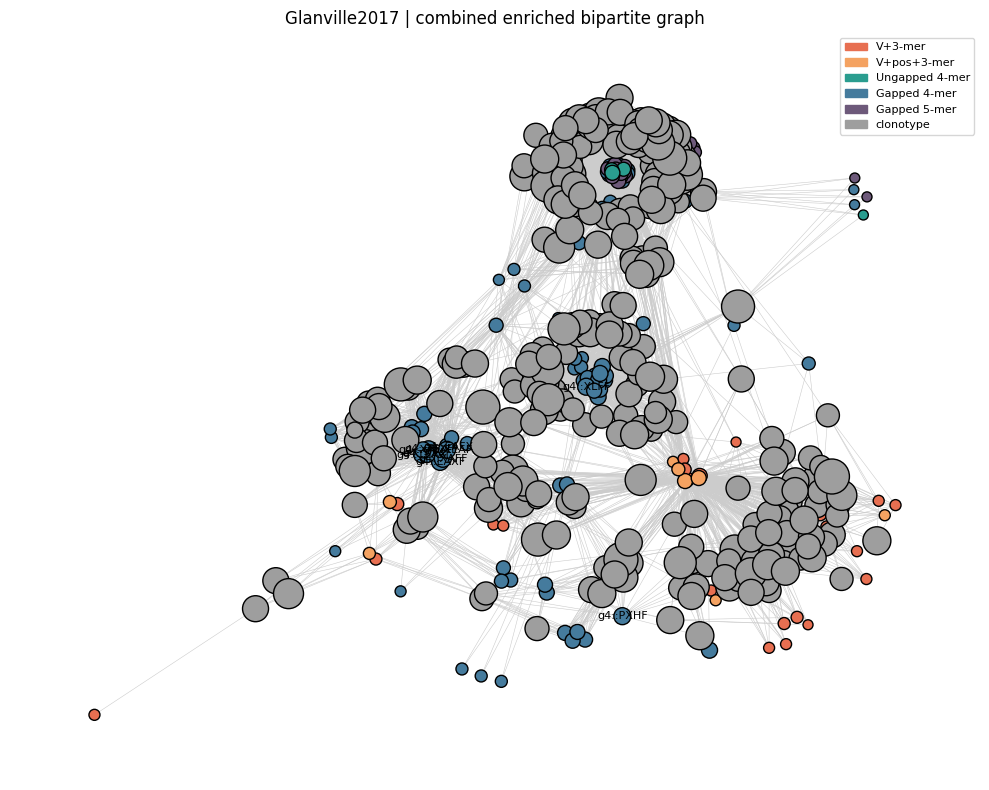

Glanville2017 | clonotype projection graph: 2018 nodes - subsampling to 450


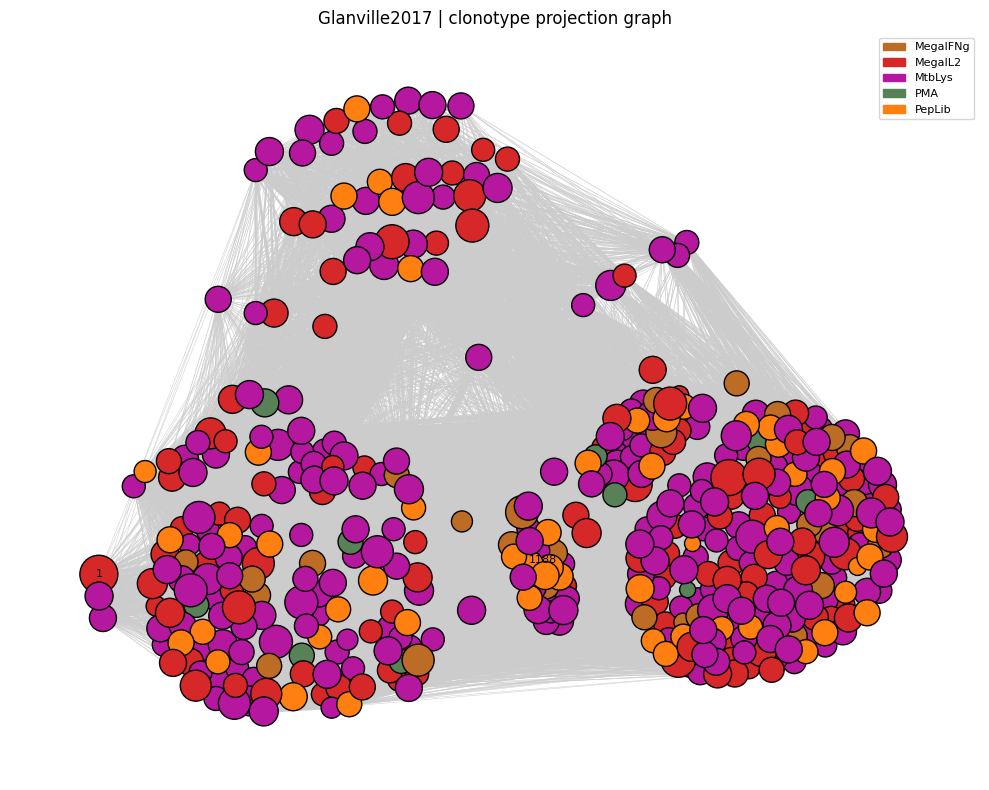

Glanville2017 | k-mer projection graph: 851 nodes - subsampling to 450


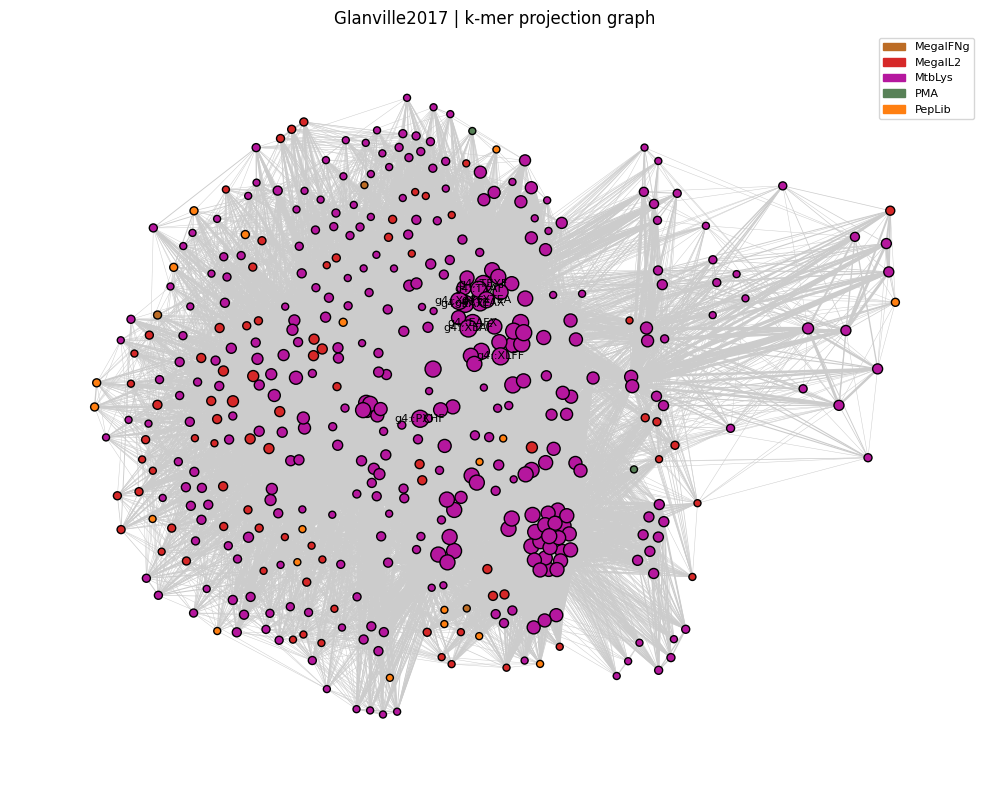


=== Huang2020 | combined enriched-token graphs ===
Enriched token counts by family: {'v3': 962, 'vpos3': 470, 'u4': 544, 'g4': 1608, 'g5': 2163}
Combined enriched token total: 5747
Combined clonotype total: 8579
Huang2020 | combined enriched bipartite graph: 14326 nodes - subsampling to 450


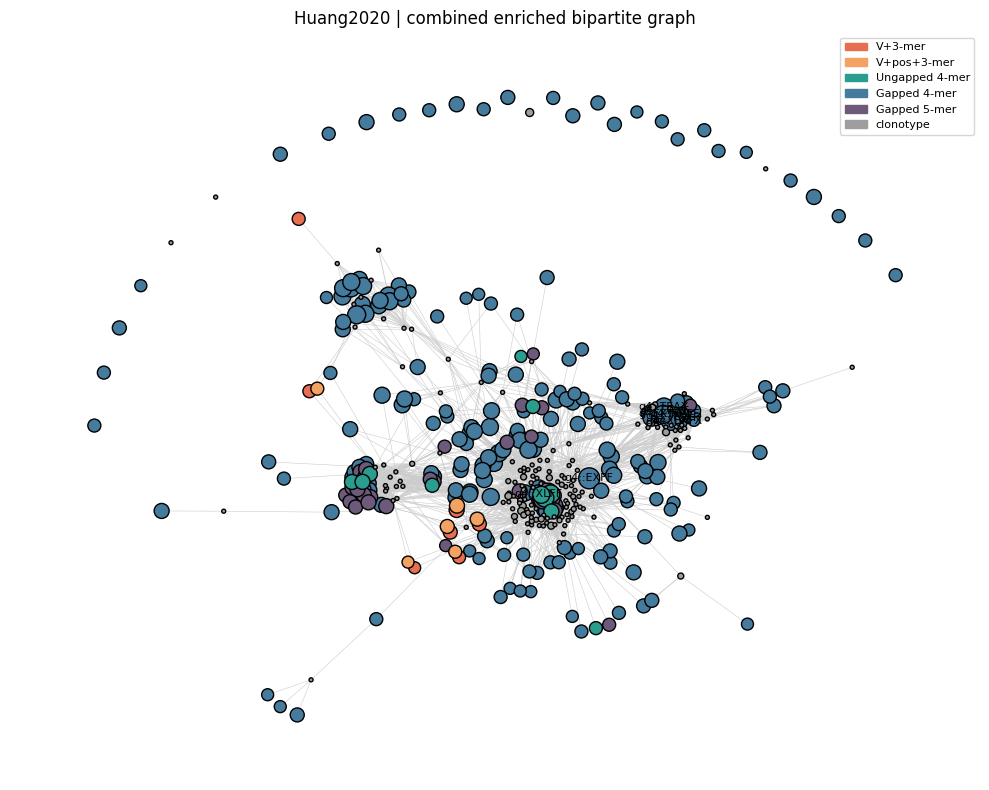

Huang2020 | clonotype projection graph: 8579 nodes - subsampling to 450


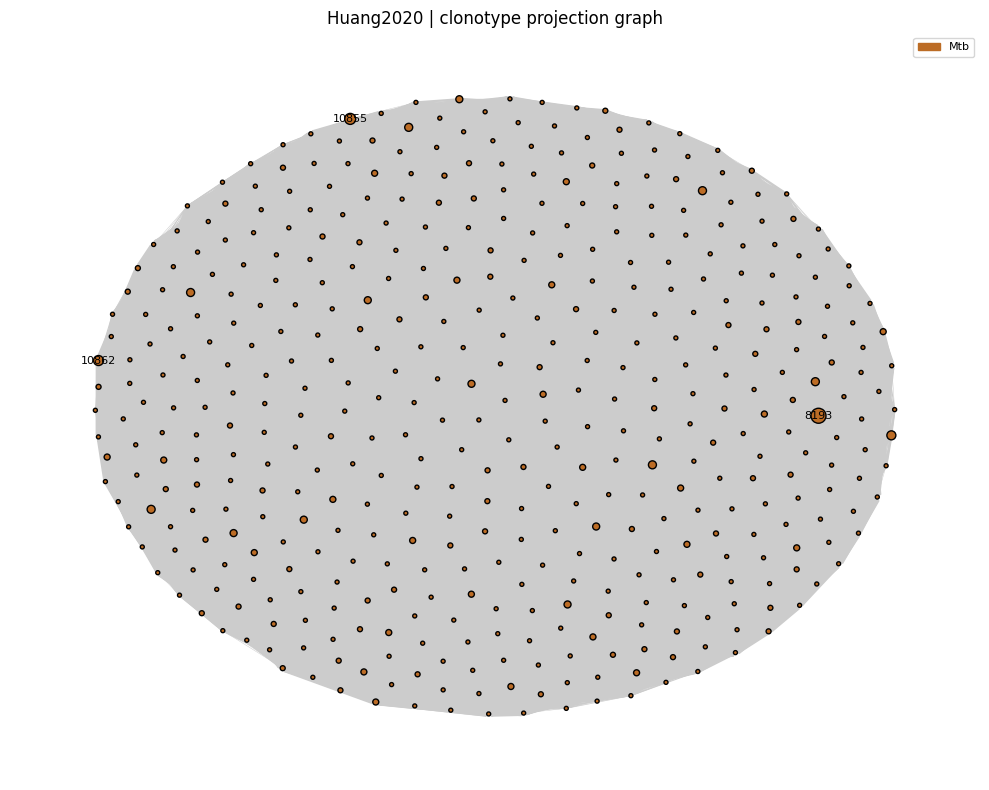

Huang2020 | k-mer projection graph: 5747 nodes - subsampling to 450


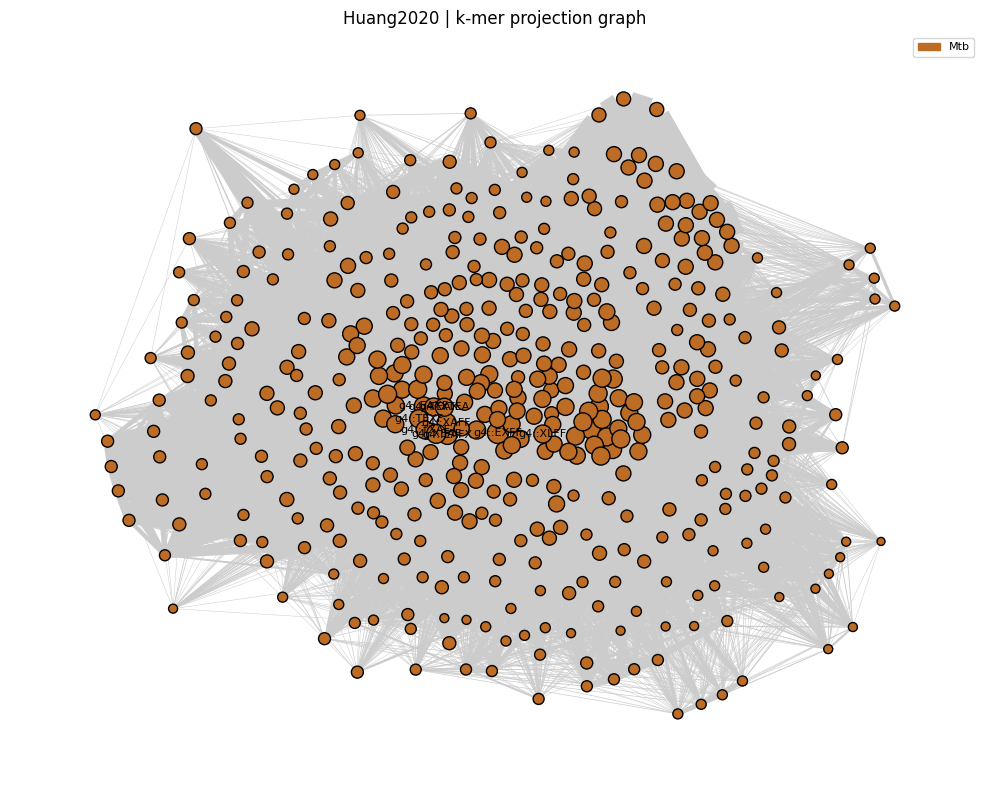

In [10]:
combined_graph_payloads: dict[str, dict[str, object]] = {}

for study in sorted(next(iter(study_results.values())).keys()):
    study_payloads = {family: study_results[family][study] for family in FAMILIES}
    study_df = study_payloads[FAMILIES[0]]['study_df']
    token_to_clones, clone_to_tokens, token_family = _build_combined_token_maps(study_payloads)
    combined_graph_payloads[study] = {
        'study_df': study_df,
        'token_to_clones': token_to_clones,
        'clone_to_tokens': clone_to_tokens,
        'token_family': token_family,
    }

    print(f'\n=== {study} | combined enriched-token graphs ===')
    family_counts = {family: len(study_payloads[family]['enriched_tokens']) for family in FAMILIES}
    print('Enriched token counts by family:', family_counts)
    print('Combined enriched token total:', len(token_to_clones))
    print('Combined clonotype total:', len(clone_to_tokens))

    bipartite_graph = _build_bipartite_graph(study_df, token_to_clones, token_family)
    _plot_graph(
        bipartite_graph,
        title=f'{study} | combined enriched bipartite graph',
        legend_items=[(FAMILY_LABELS[family], FAMILY_COLORS[family]) for family in FAMILIES] + [('clonotype', '#9e9e9e')],
        label_nodes=_top_token_labels(token_to_clones),
    )

    clone_graph = _project_clone_graph(study_df, clone_to_tokens)
    stim_legend = [(label, color) for label, color in _stimulus_color_map(study_df['stimulus']).items()]
    _plot_graph(
        clone_graph,
        title=f'{study} | clonotype projection graph',
        legend_items=stim_legend,
        label_nodes=_top_clone_labels(study_df, list(clone_to_tokens)),
    )

    kmer_graph = _project_kmer_graph(study_df, token_to_clones, token_family)
    _plot_graph(
        kmer_graph,
        title=f'{study} | k-mer projection graph',
        legend_items=stim_legend,
        label_nodes=_top_token_labels(token_to_clones),
    )


In [11]:
def _canonical_study_name(study_name: str) -> str | None:
    s = str(study_name).lower()
    for canon, keyword in STUDY_KEYWORDS.items():
        if keyword in s:
            return canon
    return None


def _purity_score(y_true: pd.Series, y_pred: pd.Series) -> float:
    tab = pd.crosstab(y_pred, y_true)
    if tab.empty:
        return float('nan')
    return float(tab.max(axis=1).sum() / tab.to_numpy().sum())


def _cluster_projected_graph(
    study_df: pd.DataFrame,
    clone_graph: ig.Graph,
    method: str,
    min_cluster_size: int = MIN_CLUSTER_SIZE,
) -> tuple[dict[str, int], dict[str, int]]:
    clone_ids_all = study_df['row_id'].astype(str).tolist()
    labels_all = {clone_id: -1 for clone_id in clone_ids_all}
    if clone_graph.vcount() == 0 or clone_graph.ecount() == 0:
        return labels_all, {'n_clusters': 0, 'n_clustered': 0, 'n_total': len(clone_ids_all)}

    if method == 'components':
        membership = np.full(clone_graph.vcount(), -1, dtype=int)
        for comp_id, vertices in enumerate(clone_graph.components()):
            for vertex in vertices:
                membership[vertex] = comp_id
    elif method == 'leiden':
        membership = np.array(
            clone_graph.community_leiden(weights='weight', objective_function='modularity', n_iterations=5).membership,
            dtype=int,
        )
    else:
        raise ValueError(f'Unknown method: {method}')

    keep_mask = np.zeros_like(membership, dtype=bool)
    for label in np.unique(membership):
        if (membership == label).sum() >= min_cluster_size:
            keep_mask |= (membership == label)
    membership = np.where(keep_mask, membership, -1)

    for clone_id, label in zip(clone_graph.vs['name'], membership):
        labels_all[str(clone_id)] = int(label)

    stats = {
        'n_clusters': int(len(set(membership[membership >= 0]))),
        'n_clustered': int((membership >= 0).sum()),
        'n_total': len(clone_ids_all),
    }
    return labels_all, stats


def _make_cluster_table(
    study_df: pd.DataFrame,
    clone_to_tokens: dict[str, set[str]],
    token_family: dict[str, str],
    labels_map: dict[str, int],
    top_n: int = 15,
) -> pd.DataFrame:
    rows = []
    study_index = study_df.set_index('row_id')
    valid_labels = sorted({label for label in labels_map.values() if label >= 0})
    for label in valid_labels:
        member_ids = [clone_id for clone_id, value in labels_map.items() if value == label]
        member_rows = study_index.loc[study_index.index.intersection(member_ids)]
        token_support = Counter()
        family_support = Counter()
        for clone_id in member_ids:
            for token in clone_to_tokens.get(clone_id, set()):
                token_support[token] += 1
                family_support[token_family.get(token, _family_from_token(token))] += 1
        top_tokens = ', '.join(
            f"{_token_display_name(token)} ({count})"
            for token, count in token_support.most_common(5)
        )
        top_families = ', '.join(f'{FAMILY_LABELS[family]}:{count}' for family, count in family_support.most_common())
        rows.append({
            'cluster': label,
            'size': len(member_ids),
            'mean_duplicate_count': float(member_rows['duplicate_count'].mean()) if len(member_rows) else np.nan,
            'top_families': top_families,
            'top_enriched_tokens': top_tokens,
            'stimuli': ', '.join(member_rows['stimulus'].astype(str).value_counts().head(3).index.tolist()),
            'sequences': ' | '.join(member_rows['junction_aa'].astype(str).tolist()[:5]),
        })
    if not rows:
        return pd.DataFrame(columns=['cluster', 'size', 'mean_duplicate_count', 'top_families', 'top_enriched_tokens', 'stimuli', 'sequences'])
    return pd.DataFrame(rows).sort_values('size', ascending=False).head(top_n)


def _concordance_row(
    study_df: pd.DataFrame,
    labels_map: dict[str, int],
    target_col: str,
    target_name: str,
    canonical_study: str | None,
    method: str,
) -> dict[str, object]:
    tmp = study_df[['row_id', target_col]].copy()
    tmp['target'] = tmp[target_col].fillna('').astype(str).str.strip()
    tmp = tmp[~tmp['target'].str.lower().isin({'', 'nan', 'none', 'na'})].copy()
    n_target_total = len(tmp)
    if n_target_total == 0:
        return {
            'canonical_study': canonical_study,
            'reference_id': str(study_df['reference_id'].iloc[0]),
            'method': method,
            'config': f'combined+{method}',
            'target_name': target_name,
            'n_total': len(study_df),
            'n_target_total': 0,
            'n_eval': 0,
            'coverage': 0.0,
            'ami': np.nan,
            'nmi': np.nan,
            'ari': np.nan,
            'purity': np.nan,
        }

    tmp['pred_cluster'] = tmp['row_id'].map(labels_map).fillna(-1).astype(int)
    coverage = float((tmp['pred_cluster'] >= 0).mean())
    eval_df = tmp[tmp['pred_cluster'] >= 0].copy()

    if len(eval_df) < 2 or eval_df['pred_cluster'].nunique() < 2 or eval_df['target'].nunique() < 2:
        ami = nmi = ari = purity = np.nan
    else:
        ami = adjusted_mutual_info_score(eval_df['target'], eval_df['pred_cluster'])
        nmi = normalized_mutual_info_score(eval_df['target'], eval_df['pred_cluster'])
        ari = adjusted_rand_score(eval_df['target'], eval_df['pred_cluster'])
        purity = _purity_score(eval_df['target'], eval_df['pred_cluster'])

    return {
        'canonical_study': canonical_study,
        'reference_id': str(study_df['reference_id'].iloc[0]),
        'method': method,
        'config': f'combined+{method}',
        'target_name': target_name,
        'n_total': len(study_df),
        'n_target_total': n_target_total,
        'n_eval': len(eval_df),
        'coverage': coverage,
        'ami': ami,
        'nmi': nmi,
        'ari': ari,
        'purity': purity,
    }


In [15]:
cluster_tables: dict[tuple[str, str], pd.DataFrame] = {}
cluster_labels: dict[tuple[str, str], dict[str, int]] = {}
cluster_stats_rows: list[dict[str, object]] = []
concordance_rows: list[dict[str, object]] = []

for study, payload in combined_graph_payloads.items():
    study_df = payload['study_df']
    clone_to_tokens = payload['clone_to_tokens']
    token_family = payload['token_family']
    weighted_clone_graph = _build_weighted_clone_graph(
        study_df,
        payload['token_to_clones'],
        min_weight=CLONE_EDGE_MIN_WEIGHT,
    )
    canonical = _canonical_study_name(study)
    total_enriched = len(payload['token_to_clones'])

    for method in CLUSTER_METHODS:
        labels_map, stats = _cluster_projected_graph(
            study_df,
            weighted_clone_graph,
            method=method,
            min_cluster_size=MIN_CLUSTER_SIZE,
        )
        cluster_labels[(study, method)] = labels_map
        cluster_tables[(study, method)] = _make_cluster_table(study_df, clone_to_tokens, token_family, labels_map)

        cluster_stats_rows.append({
            'canonical_study': canonical,
            'reference_id': study,
            'method': method,
            'config': f'combined+{method}',
            'n_enriched_tokens_total': total_enriched,
            'n_clusters': stats['n_clusters'],
            'n_clustered': stats['n_clustered'],
            'n_total': stats['n_total'],
            'clustered_frac': stats['n_clustered'] / stats['n_total'] if stats['n_total'] else np.nan,
        })

        concordance_rows.append(_concordance_row(
            study_df=study_df,
            labels_map=labels_map,
            target_col='gliph_cluster_id',
            target_name='gliph_cluster_id',
            canonical_study=canonical,
            method=method,
        ))
        if canonical == 'Glanville2017':
            concordance_rows.append(_concordance_row(
                study_df=study_df,
                labels_map=labels_map,
                target_col='stimulus',
                target_name='stimulus',
                canonical_study=canonical,
                method=method,
            ))
        elif canonical == 'Huang2020':
            concordance_rows.append(_concordance_row(
                study_df=study_df,
                labels_map=labels_map,
                target_col='epitope',
                target_name='epitope',
                canonical_study=canonical,
                method=method,
            ))

cluster_stats_df = pd.DataFrame(cluster_stats_rows).sort_values(
    ['canonical_study', 'reference_id', 'method']
).reset_index(drop=True)
concordance_df = pd.DataFrame(concordance_rows).sort_values(
    ['canonical_study', 'reference_id', 'target_name', 'method']
).reset_index(drop=True)

print('Cluster statistics table:')
display(cluster_stats_df)

print('Concordance table:')
display(concordance_df)


Cluster statistics table:


,canonical_study,reference_id,method,config,n_enriched_tokens_total,n_clusters,n_clustered,n_total,clustered_frac
0,Glanville2017,Glanville2017,components,combined+components,851,12,339,3928,0.086303
1,Glanville2017,Glanville2017,leiden,combined+leiden,851,21,339,3928,0.086303
2,Huang2020,Huang2020,components,combined+components,5747,87,2429,9934,0.244514
3,Huang2020,Huang2020,leiden,combined+leiden,5747,135,2427,9934,0.244312


Concordance table:


,canonical_study,reference_id,method,config,target_name,n_total,n_target_total,n_eval,coverage,ami,nmi,ari,purity
0,Glanville2017,Glanville2017,components,combined+components,gliph_cluster_id,3928,1287,128,0.099456,0.084427,0.368383,0.023842,0.234375
1,Glanville2017,Glanville2017,leiden,combined+leiden,gliph_cluster_id,3928,1287,128,0.099456,0.280422,0.720245,0.244090,0.343750
2,Glanville2017,Glanville2017,components,combined+components,stimulus,3928,3928,339,0.086303,-0.000253,0.057524,-0.036607,0.513274
3,Glanville2017,Glanville2017,leiden,combined+leiden,stimulus,3928,3928,339,0.086303,-0.001998,0.060594,-0.014050,0.519174
4,Huang2020,Huang2020,components,combined+components,epitope,9934,0,0,0.000000,NaN,NaN,NaN,NaN
5,Huang2020,Huang2020,leiden,combined+leiden,epitope,9934,0,0,0.000000,NaN,NaN,NaN,NaN
6,Huang2020,Huang2020,components,combined+components,gliph_cluster_id,9934,4493,1442,0.320944,0.045251,0.257275,0.000647,0.122053
7,Huang2020,Huang2020,leiden,combined+leiden,gliph_cluster_id,9934,4493,1440,0.320499,0.288213,0.741849,0.076680,0.239583



=== combined graph + components | Glanville2017 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
0,5,279,3993.566308,"V+3-mer:2546, V+pos+3-mer:1489, Gapped 4-mer:8...","TRBV12-3:CAS (206), TRBV12-3@0:CAS (206), TRBV...","MtbLys, MegaIL2, PepLib",CASSKLEGLEQFF | CASRRQGGAYEQYF | CASSLDVDYGYTF...
4,121,26,4518.846154,"Gapped 5-mer:200, Gapped 4-mer:194, Ungapped 4...","SXAL (18), VALX (17), XVAL (17), SVAL (17), XS...","MtbLys, MegaIL2, MegaIFNg",CSASVRLFGTDTQYF | CASSVALMGGELFF | CSVALSGQGKY...
5,140,5,4414.200000,"Gapped 4-mer:49, Gapped 5-mer:4","XDQN (5), DQNX (5), DQNXE (4), XEAF (3), NTEX (3)","MtbLys, PMA, MegaIL2",CSGKGTDQNTEAFF | CASSLDQNNEQFF | CASSPDQNTEAFF...
1,52,4,2122.000000,"Gapped 4-mer:14, Gapped 5-mer:2","WXKA (3), RAWXK (2), XAFF (1), GXAF (1), XLHF (1)","MtbLys, PepLib",CASSLRAWGKADYGYTF | CASGWDKASANNEQFF | CASSRLQ...
8,364,4,7429.500000,Gapped 4-mer:51,"XRSM (4), RSMX (4), EAFX (2), XEAF (2), TEAX (2)","MtbLys, MegaIL2, MegaIFNg",CASNRQPRSMGTEAFF | CASSYRSMEKLFF | CASSRSMMGTG...
2,65,3,3078.666667,"Gapped 4-mer:15, Gapped 5-mer:4","HTXNN (2), QHTXN (2), XQHF (1), PXHF (1), XEAF...","MegaIL2, MtbLys",CASSNLQHTNNNQPQHF | CSLPGQHTLNTEAFF | CSATDIHT...
3,67,3,1241.666667,"Gapped 4-mer:41, V+pos+3-mer:12","XELF (3), TGEX (3), GEXF (3), TRBV6-5@12:TGE (...",MtbLys,CASSSLFSGRSGTGELFF | CASSYSSPGTVNTGELFF | CASS...
6,253,3,2840.333333,Gapped 4-mer:20,"RXQM (3), MNXE (2), XEAF (1), NTEX (1), NXEA (1)","MegaIL2, MtbLys",CASTRGQMNYEQYF | CAWRGQMNTEAFF | CSARDPRHQMDTQYF
7,306,3,2036.000000,Gapped 4-mer:6,"VXHF (3), XLHF (2), XQHF (1)","MtbLys, MegaIL2",CASSLSRQGRFVLHF | CASSPQSPVQHF | CASHRDMVLHF
9,548,3,2419.333333,"Gapped 4-mer:29, Gapped 5-mer:6, Ungapped 4-mer:2","IXPI (3), VIXPI (2), IGPIX (2), XIGPI (2), IGP...","MtbLys, MegaIL2",CSVIRPIQGYTGELFF | CASSIGPIGRNTEAFF | CASSVIGP...



=== combined graph + leiden | Glanville2017 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
4,18,62,2633.548387,"V+3-mer:502, V+pos+3-mer:246, Gapped 4-mer:154...","TRBV6-2:CAS (60), TRBV6-2@0:CAS (60), TRBV6-2@...","MtbLys, MegaIL2, PepLib",CASRGTGTGNYGYTF | CASRGTGRTGNTIYF | CASSKLGNEQ...
1,7,55,5126.727273,"V+3-mer:520, V+pos+3-mer:341, Gapped 4-mer:25","TRBV12-3@0:CAS (53), TRBV12-3:CAS (53), TRBV12...","MegaIL2, MtbLys, PepLib",CASRRQGGAYEQYF | CASSLDVDYGYTF | CASSTLRLRNIQY...
0,5,44,5625.977273,"V+3-mer:368, V+pos+3-mer:230, Gapped 4-mer:230...","TRBV12-3:CAS (40), TRBV12-3@0:CAS (40), TRBV12...","MtbLys, MegaIL2, PepLib",CASSKLEGLEQFF | CASSQLENTEAFF | CASSLIENTEAFF ...
3,17,39,4707.128205,"V+3-mer:389, Gapped 4-mer:240, V+pos+3-mer:215","TRBV12-3@0:CAS (38), TRBV12-3:CAS (38), TRBV12...","MtbLys, MegaIL2, PepLib",CASSLGQTSYNSPLHF | CASSSSGTGEKLFF | CASSSGPLNS...
6,39,38,2786.605263,"V+3-mer:355, V+pos+3-mer:228, Gapped 4-mer:17,...","TRBV12-3:CAS (36), TRBV12-3@0:CAS (36), TRBV12...","MtbLys, MegaIL2, PepLib",CASSLQEKQETQYF | CASSPGLTSWSSTDTQYF | CASSFRTS...
10,127,17,4419.470588,"Gapped 5-mer:93, Gapped 4-mer:88, Ungapped 4-m...","VALX (17), XVAL (17), SVAL (17), XSVAL (17), S...","MtbLys, MegaIL2, MegaIFNg",CASSVALMGGELFF | CSVALSGQGKYF | CASSVALYANEQFF...
2,10,11,1893.818182,"V+3-mer:127, V+pos+3-mer:51, Gapped 4-mer:4","TRBV12-3@0:CAS (11), TRBV12-3:CAS (11), TRBV12...","MtbLys, MegaIL2, MegaIFNg",CASLRASGANVLTF | CASRYRHRDALGQPQHF | CASSPHRRV...
12,162,11,5491.272727,"V+3-mer:108, V+pos+3-mer:60, Gapped 4-mer:18","TRBV12-3:CAS (10), TRBV12-3@0:CAS (10), TRBV12...","MegaIL2, MtbLys, PepLib",CASTNSGSNQPQHF | CASSEGVNEQYF | CASSLSVTGVQPQH...
13,185,10,2128.400000,"V+3-mer:87, V+pos+3-mer:59, Gapped 5-mer:4, Un...","TRBV12-3@11:EQF (9), TRBV12-3:QFF (9), TRBV12-...","MtbLys, MegaIL2",CASRLGGLAEDEQFF | CASSSRDGRYNEQFF | CASSLGALGI...
5,20,9,3269.222222,"Gapped 4-mer:124, Gapped 5-mer:105, V+3-mer:90...","XNTI (9), NTXY (9), XIYF (9), XTIYF (9), TRBV1...","MegaIL2, MtbLys, PepLib",CASSLVTAGNTIYF | CASSLSQPAGNTIYF | CASSRDGRGPG...



=== combined graph + components | Huang2020 ===


...


=== combined graph + leiden | Huang2020 ===


,cluster,size,mean_duplicate_count,top_families,top_enriched_tokens,stimuli,sequences
14,71,187,1.299465,"V+3-mer:1420, Gapped 4-mer:1311, V+pos+3-mer:8...","TRBV12-3:CAS (141), TRBV12-3@0:CAS (141), TRBV...",Mtb,CASSPLVAGSSYEQYF | CASTHGLAVYNEQFF | CASVGHTEA...
24,155,147,1.176871,"Gapped 4-mer:1291, Gapped 5-mer:383, Ungapped ...","EXFF (33), XLFF (12), XAFF (12), GGXG (12), XE...",Mtb,CASSFGRLAYPEQYF | CASSLVGHEVCREETQYF | CATRSAG...
23,136,124,1.322581,"Gapped 4-mer:946, V+3-mer:833, V+pos+3-mer:499...","TRBV6-2@0:CAS (87), TRBV6-2:CAS (87), TRBV6-2:...",Mtb,CASRSRGGRTYNEQFF | CASTLTGHTGELFF | CASRSGLMNT...
40,347,113,1.309735,"Gapped 4-mer:1270, Gapped 5-mer:680, Ungapped ...","EXFF (24), AXSC (24), CAXSC (24), XSSC (23), S...",Mtb,CASCGSSYNSPLHF | CASCLFGGGNSPLHF | CASSCLQGASG...
3,9,90,1.288889,"Gapped 4-mer:851, Gapped 5-mer:433, Ungapped 4...","EXFF (46), KEXFF (25), KEXF (25), KEQX (24), X...",Mtb,CASSLDPEDANTGELFF | CASSMPGLSGPKEQFF | CASSMPG...
0,1,82,1.573171,"Gapped 4-mer:538, Gapped 5-mer:331, Ungapped 4...","GQXF (20), XYGQ (20), YGQX (20), YGQXF (16), Y...",Mtb,CASSKDSGLPYEQYF | CASSLDAHYTGQFF | CASSPGDEQDF...
2,8,74,1.364865,"Gapped 4-mer:792, Gapped 5-mer:282, Ungapped 4...","XQHF (27), QXQH (23), PQXF (20), QPQX (19), XQ...",Mtb,CASSGIRRRLRLAGGHDEQFF | CASSGIRRRLRLAGGHEEQFF ...
18,105,73,1.095890,"Gapped 4-mer:779, Gapped 5-mer:287, Ungapped 4...","CXRS (27), ARSX (23), XARS (23), EXFF (23), CA...",Mtb,CASSPPGGTGWISNQPQHF | CTTPGTSGRNEQYF | CACSGGV...
39,346,70,1.514286,"Gapped 4-mer:473, Gapped 5-mer:307, V+pos+3-me...","CGXS (19), CGAX (18), TRBV20-1@0:CGA (17), TRB...",Mtb,CGARGRVEYEEDF | CASGHSPGGGYYEHYF | CASSFGPGQGA...
25,161,67,1.283582,"Gapped 4-mer:656, Gapped 5-mer:293, Ungapped 4...","EXFF (26), CDSX (17), XAFF (16), EAXF (15), EA...",Mtb,CASSLALNTEAFF | CDSSFGAGGGEQYF | CASHRTYPAVATP...


,canonical_study,reference_id,method,config,target_name,n_total,n_target_total,n_eval,coverage,ami,nmi,ari,purity
0,Glanville2017,Glanville2017,components,combined+components,gliph_cluster_id,3928,1287,128,0.099456,0.084427,0.368383,0.023842,0.234375
1,Glanville2017,Glanville2017,leiden,combined+leiden,gliph_cluster_id,3928,1287,128,0.099456,0.280422,0.720245,0.244090,0.343750
2,Glanville2017,Glanville2017,components,combined+components,stimulus,3928,3928,339,0.086303,-0.000253,0.057524,-0.036607,0.513274
3,Glanville2017,Glanville2017,leiden,combined+leiden,stimulus,3928,3928,339,0.086303,-0.001998,0.060594,-0.014050,0.519174
4,Huang2020,Huang2020,components,combined+components,epitope,9934,0,0,0.000000,NaN,NaN,NaN,NaN
5,Huang2020,Huang2020,leiden,combined+leiden,epitope,9934,0,0,0.000000,NaN,NaN,NaN,NaN
6,Huang2020,Huang2020,components,combined+components,gliph_cluster_id,9934,4493,1442,0.320944,0.045251,0.257275,0.000647,0.122053
7,Huang2020,Huang2020,leiden,combined+leiden,gliph_cluster_id,9934,4493,1440,0.320499,0.288213,0.741849,0.076680,0.239583


Target-label availability:


,study,n_rows,n_with_gliph_cluster_id,n_with_stimulus,n_with_epitope
0,Glanville2017,3928,1287,3928,0
1,Huang2020,9934,4493,9934,0


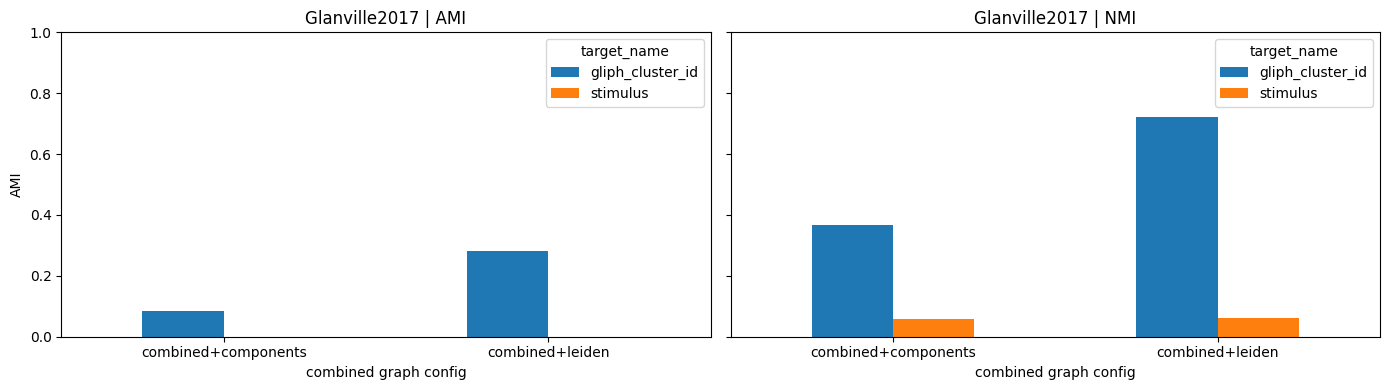

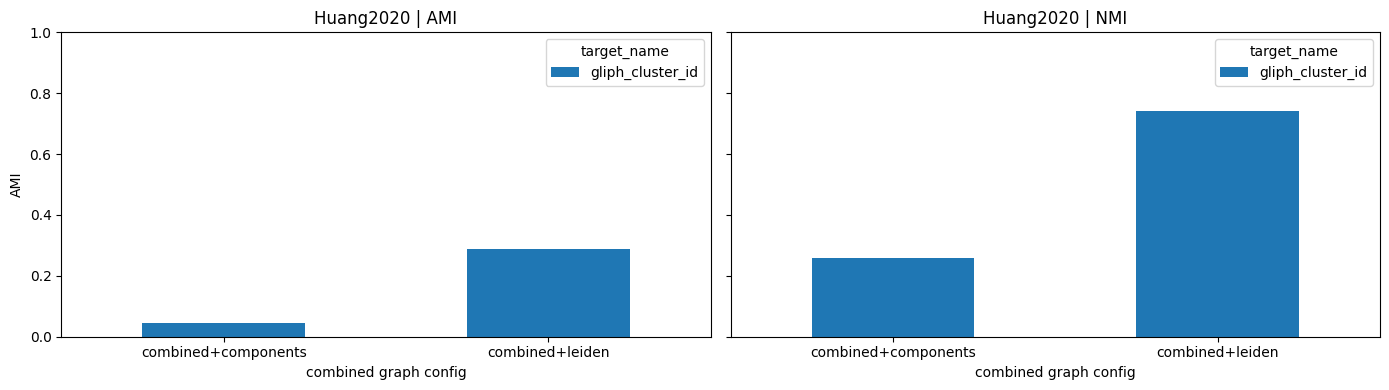

## End-of-Notebook Summary

- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.
- Token extraction uses `clonotype` counts, `4` threads, `CONTROL_SAMPLE=1,000,000`, and V-only control normalization.
- Separate Fisher tests were run for `v3`, `vpos3`, `u4`, `g4`, and `g5` with the graph cutoff `FDR < 0.05`, `odds > 1.0`, and `sample_clonotypes >= 2`.
- Final graph analysis merges all enriched tokens across families into one bipartite graph per study, then projects to clonotype and k-mer graphs.
- Bipartite graph styling: k-mers are colored by family and sized by enriched-neighbor degree; clonotypes are grey and sized by `log2(duplicate_count + 1)`.
- Clonotype projection styling: nodes are colored by `stimulus` and sized by `log2(duplicate_count + 1)`; concordance is computed on its components and Leiden communities.
- K-mer projection styling: nodes are colored by the dominant stimulus of neighboring clonotypes.
- Concordance targets:
  - `Glanville2017`: `stimulus` and `gliph_cluster_id`
  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)
- Cluster tables now rank top enriched tokens by within-community support, so the listed motifs are guaranteed to come from the displayed member clonotypes.
- Glanville2017 enriched token counts: v3=442, vpos3=206, u4=20, g4=109, g5=74.
- Huang2020 enriched token counts: v3=962, vpos3=470, u4=544, g4=1608, g5=2163.
- Glanville2017 vs gliph_cluster_id: best `combined+leiden` with AMI=0.280, NMI=0.720, ARI=0.244, purity=0.344, coverage=9.9%.
- Glanville2017 vs stimulus: best `combined+components` with AMI=-0.000, NMI=0.058, ARI=-0.037, purity=0.513, coverage=8.6%.
- Huang2020 vs gliph_cluster_id: best `combined+leiden` with AMI=0.288, NMI=0.742, ARI=0.077, purity=0.240, coverage=32.0%.
- Huang2020 vs epitope: no non-empty labels in this dataset snapshot.

In [16]:
# Top cluster previews per study and graph community method
for key in sorted(cluster_tables.keys()):
    study, method = key
    tab = cluster_tables[key]
    print(f'\n=== combined graph + {method} | {study} ===')
    if tab.empty:
        print('  (no clusters)')
    else:
        display(tab.head(10))

focus_studies = {'Glanville2017', 'Huang2020'}
focus_conc = concordance_df[concordance_df['canonical_study'].isin(focus_studies)].copy()
display(focus_conc)

availability_rows = []
for study_name in sorted(focus_studies):
    sdf = df[df['reference_id'].str.contains(STUDY_KEYWORDS[study_name], case=False, na=False)].copy()
    if sdf.empty:
        continue
    availability_rows.append({
        'study': study_name,
        'n_rows': len(sdf),
        'n_with_gliph_cluster_id': int((sdf['gliph_cluster_id'].fillna('').astype(str).str.strip() != '').sum()),
        'n_with_stimulus': int((sdf['stimulus'].fillna('').astype(str).str.strip() != '').sum()),
        'n_with_epitope': int((sdf['epitope'].fillna('').astype(str).str.strip() != '').sum()),
    })
availability_df = pd.DataFrame(availability_rows)
print('Target-label availability:')
display(availability_df)

config_order = [f'combined+{method}' for method in CLUSTER_METHODS]
for study_name in sorted(focus_conc['canonical_study'].dropna().unique()):
    study_df_plot = focus_conc[focus_conc['canonical_study'] == study_name].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, metric in zip(axes, ['ami', 'nmi']):
        piv = study_df_plot.pivot_table(
            index='config', columns='target_name', values=metric, aggfunc='mean'
        ).reindex(config_order)
        piv.plot(kind='bar', ax=ax)
        ax.set_title(f'{study_name} | {metric.upper()}')
        ax.set_xlabel('combined graph config')
        ax.set_ylabel(metric.upper())
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

requested_targets = {
    'Glanville2017': ['gliph_cluster_id', 'stimulus'],
    'Huang2020': ['gliph_cluster_id', 'epitope'],
}
best_rows = []
for study_name, targets in requested_targets.items():
    for target_name in targets:
        sub_all = focus_conc[
            (focus_conc['canonical_study'] == study_name)
            & (focus_conc['target_name'] == target_name)
        ].copy()
        if sub_all.empty:
            best_rows.append(f'- {study_name} vs {target_name}: no rows available in concordance table.')
            continue
        if int(sub_all['n_target_total'].max()) == 0:
            best_rows.append(f'- {study_name} vs {target_name}: no non-empty labels in this dataset snapshot.')
            continue
        sub = sub_all.dropna(subset=['ami']).copy()
        if sub.empty:
            best_rows.append(
                f"- {study_name} vs {target_name}: labels exist but no evaluable configuration (needs >=2 predicted communities and >=2 target classes)."
            )
            continue
        row = sub.sort_values(['ami', 'n_eval'], ascending=[False, False]).iloc[0]
        best_rows.append(
            f"- {study_name} vs {target_name}: best `{row['config']}` with AMI={row['ami']:.3f}, NMI={row['nmi']:.3f}, ARI={row['ari']:.3f}, purity={row['purity']:.3f}, coverage={row['coverage']:.1%}."
        )

family_count_lines = []
for study in sorted(combined_graph_payloads):
    counts = {family: len(study_results[family][study]['enriched_tokens']) for family in FAMILIES}
    formatted = ', '.join(f"{family}={counts[family]}" for family in FAMILIES)
    family_count_lines.append(f'- {study} enriched token counts: {formatted}.')

summary_lines = [
    '## End-of-Notebook Summary',
    '',
    '- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.',
    f'- Token extraction uses `{COUNT_MODE}` counts, `{TOKEN_THREADS}` threads, `CONTROL_SAMPLE={CONTROL_SAMPLE:,}`, and V-only control normalization.',
    '- Separate Fisher tests were run for `v3`, `vpos3`, `u4`, `g4`, and `g5` with the graph cutoff `FDR < 0.05`, `odds > 1.0`, and `sample_clonotypes >= 2`.',
    '- Final graph analysis merges all enriched tokens across families into one bipartite graph per study, then projects to clonotype and k-mer graphs.',
    '- Bipartite graph styling: k-mers are colored by family and sized by enriched-neighbor degree; clonotypes are grey and sized by `log2(duplicate_count + 1)`.',
    '- Clonotype projection styling: nodes are colored by `stimulus` and sized by `log2(duplicate_count + 1)`; concordance is computed on its components and Leiden communities.',
    '- K-mer projection styling: nodes are colored by the dominant stimulus of neighboring clonotypes.',
    '- Concordance targets:',
    '  - `Glanville2017`: `stimulus` and `gliph_cluster_id`',
    '  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)',
    '- Cluster tables now rank top enriched tokens by within-community support, so the listed motifs are guaranteed to come from the displayed member clonotypes.',
]
summary_lines.extend(family_count_lines)
summary_lines.extend(best_rows)
display(Markdown('\n'.join(summary_lines)))

## Brief Conclusions and Context

- This pipeline reproduces a core GLIPH-like idea: motif/token enrichment against controls, followed by motif-linked clustering.
- Compared to **Huang et al., 2020 (Nat Biotech)** (https://www.nature.com/articles/s41587-020-0505-4), this notebook is a lighter implementation and does not include all GLIPH2 constraints (e.g., global/local motif scoring calibration and full HLA-aware priors).
- Relative to **Glanville et al., 2017 (Nature)** (https://pubmed.ncbi.nlm.nih.gov/28636589/), the bipartite token graph here captures motif-sharing structure similarly, but exact cluster boundaries may differ because we use explicit Fisher enrichment + FDR thresholds and connected-component/community heuristics.
- Practical interpretation:
  - Higher Cramer's V / AMI / NMI and lower stimulated-unclustered fraction indicate better stimulus separation by token-defined clusters.
  - Silhouette can be conservative in sparse high-dimensional token spaces; use it together with chi2/Cramer's V and cluster composition tables.

A run-specific summary is generated in the final code cell as **End-of-Notebook Summary** after all computations complete.

In [17]:
# Repeat final summary at literal notebook end for convenience.
if 'summary_lines' in globals():
    display(Markdown('\n'.join(summary_lines)))
else:
    print('Run the previous analysis cell first to generate end-of-notebook summary.')

## End-of-Notebook Summary

- GLIPH input was deduplicated to unique `(reference_id, v_gene, junction_aa)` clonotypes before token counting.
- Token extraction uses `clonotype` counts, `4` threads, `CONTROL_SAMPLE=1,000,000`, and V-only control normalization.
- Separate Fisher tests were run for `v3`, `vpos3`, `u4`, `g4`, and `g5` with the graph cutoff `FDR < 0.05`, `odds > 1.0`, and `sample_clonotypes >= 2`.
- Final graph analysis merges all enriched tokens across families into one bipartite graph per study, then projects to clonotype and k-mer graphs.
- Bipartite graph styling: k-mers are colored by family and sized by enriched-neighbor degree; clonotypes are grey and sized by `log2(duplicate_count + 1)`.
- Clonotype projection styling: nodes are colored by `stimulus` and sized by `log2(duplicate_count + 1)`; concordance is computed on its components and Leiden communities.
- K-mer projection styling: nodes are colored by the dominant stimulus of neighboring clonotypes.
- Concordance targets:
  - `Glanville2017`: `stimulus` and `gliph_cluster_id`
  - `Huang2020`: `gliph_cluster_id` only in the current dataset snapshot (`epitope` is empty)
- Cluster tables now rank top enriched tokens by within-community support, so the listed motifs are guaranteed to come from the displayed member clonotypes.
- Glanville2017 enriched token counts: v3=442, vpos3=206, u4=20, g4=109, g5=74.
- Huang2020 enriched token counts: v3=962, vpos3=470, u4=544, g4=1608, g5=2163.
- Glanville2017 vs gliph_cluster_id: best `combined+leiden` with AMI=0.280, NMI=0.720, ARI=0.244, purity=0.344, coverage=9.9%.
- Glanville2017 vs stimulus: best `combined+components` with AMI=-0.000, NMI=0.058, ARI=-0.037, purity=0.513, coverage=8.6%.
- Huang2020 vs gliph_cluster_id: best `combined+leiden` with AMI=0.288, NMI=0.742, ARI=0.077, purity=0.240, coverage=32.0%.
- Huang2020 vs epitope: no non-empty labels in this dataset snapshot.